# Module 8 · Lab 8.2 — CrewAI Agent ADK: FinTech Content Pipeline
## Role-based agents and tasks, run two ways — sequential, then hierarchical

**Scenario.** *BrightFin Media* — a fintech-focused content marketing agency in Mumbai serving 12 financial-services clients across India. The current Researcher → Writer → Editor → Compliance handoff chain runs on email and takes 3.5 days per post, with a 42% revision rate and 18% compliance flag rate. We replace the email chain with a CrewAI multi-agent pipeline.

**Learning Objectives.** By the end of this lab, you will be able to:
1. Define **CrewAI agents** with `role`, `goal`, and `backstory` — the framework's core mental model.
2. Define `Task` objects whose outputs flow as context to the next task in a `Crew`.
3. Run a `Crew` in `Process.sequential` mode (deterministic, fixed order).
4. Run a `Crew` in `Process.hierarchical` mode (manager LLM delegates dynamically).
5. Articulate when to reach for **CrewAI** (role-based content workflows) versus **LangGraph** (graph-based compliance / routing) versus the **OpenAI Agents SDK** (handoff-based, OpenAI-native).

**Why this lab matters for your client work.** Most enterprise content / research / drafting workflows today run as email chains between specialists. CrewAI gives you the cleanest mapping from that org chart onto a multi-agent system — each agent's `role` corresponds to a job title, `goal` to their KRA, `backstory` to their domain expertise. Once trainees see this mapping, they stop trying to model creative pipelines as state machines.

---


> 🗺️ **Workshop run-list.**
> **Live in session:** §1–11 (the crew — sequential, then hierarchical with a manager), §13–15 (framework comparison and the selection rule)
> **After the session:** §12 the CrewAI Flows aside, §16 stretch exercise — kept in full so you can finish at your own pace (marked ⏭️).

## 1. Install Dependencies

One package, one deliberate pin. Everywhere else in this program we install unpinned with `-qU`;
here we bound CrewAI to its 1.x major line, because 0.x and 1.x are different enough that a stray
0.x resolution breaks every cell below. The cell also refuses to run on Python 3.14 — see the
comment for why that failure is worth catching early.


In [1]:
# 📦 Packages this notebook needs. On the workshop VM they are pre-installed from
# the workshop's requirements.txt, so the install line below stays commented out.
# Running somewhere else (Colab, your own laptop)? Uncomment it and run this cell once.
# ONE deliberate exception to this program's no-pin rule: CrewAI's 1.x line renamed and moved
# enough of its surface that a 0.x resolution would break every cell below, so we bound the
# major version — and only the major version — while still taking the newest 1.x release.
import sys

# 🐍 crewai 1.x declares `requires_python = <3.14,>=3.10`. On Python 3.14 pip does NOT error:
# it silently back-solves to crewai 0.11.2 (February 2024, the newest release with no 3.14 bound)
# and the lab then dies in bewildering ways. Colab is on 3.12, so Colab is safe; this guard is
# for local venvs. Fail loudly here instead of mysteriously twenty cells later.
assert (3, 10) <= sys.version_info < (3, 14), (
    f"This lab needs Python 3.10–3.13; you are on "
    f"{sys.version_info.major}.{sys.version_info.minor}. "
    "Create a 3.12 venv, or just run the notebook on Google Colab."
)

# python-dotenv is NOT listed on purpose: it is already a core runtime dependency of crewai 1.x,
# so the loader cell's local `.env` branch works from this one install.

# !pip install -qU "crewai>=1.15,<2"

from importlib.metadata import PackageNotFoundError, version

NOTEBOOK_PACKAGES = [
    "crewai",
]
for package_name in NOTEBOOK_PACKAGES:
    try:
        print(f"{package_name:<26} {version(package_name)}")
    except PackageNotFoundError:
        print(f"{package_name:<26} NOT INSTALLED — uncomment the !pip line above")

crewai                     1.15.23


In [2]:
import crewai

In [3]:
%pip show crewai

Note: you may need to restart the kernel to use updated packages.


C:\Users\participant\.venvs\workshop\Scripts\python.exe: No module named pip


## 2. API Key Configuration

CrewAI 1.x talks to providers **natively**. The `crewai` package depends on `openai<3,>=2.30.0` directly and ships built-in providers for OpenAI, Anthropic, Gemini, Bedrock and others — so the `llm="openai/gpt-4.1-mini"` string you will see below is resolved by CrewAI's own OpenAI provider, not by a translation layer.

**LiteLLM is not a core dependency.** It is an opt-in extra (`pip install 'crewai[litellm]'`) that CrewAI falls back to only for models it does not recognise natively. So "any provider works" is too glib: switching to another *native* provider means installing that provider's extra and setting its key — the stretch exercise walks through the Anthropic case. This lab uses OpenAI only, so `OPENAI_API_KEY` is the single key you need.


In [4]:
import os

# Where to create each key. The trainer supplies OPENAI_API_KEY on the workshop VM;
# you create any other key yourself and add it to the workshop's .env file as KEY_NAME=value.
KEY_SIGNUP_PAGES = {
    "OPENAI_API_KEY": "supplied on the workshop VM (elsewhere: https://platform.openai.com/api-keys)",
    "TAVILY_API_KEY": "https://app.tavily.com (free tier)",
    "GROQ_API_KEY": "https://console.groq.com/keys (free tier)",
    "WEATHER_API_KEY": "https://www.weatherapi.com/signup.aspx (free tier)",
    "LANGSMITH_API_KEY": "https://smith.langchain.com -> Settings -> API Keys (free tier)",
    "ANTHROPIC_API_KEY": "https://console.anthropic.com/settings/keys",
    "GEMINI_API_KEY": "https://aistudio.google.com/app/apikey",
}


def load_keys(required):
    """Load API keys from Colab Secrets (on Colab) or a local .env file (elsewhere).

    Prints one line per key, then stops with instructions if a required key is missing.

    Args:
        required: the environment-variable names this lab needs.
    """
    try:
        from google.colab import userdata          # running on Google Colab
        for key_name in required:
            try:
                os.environ[key_name] = userdata.get(key_name)
            except Exception:
                pass                                 # not set in Colab Secrets
        source = "Colab Secrets"
    except ImportError:                              # the workshop VM, or any local machine
        from dotenv import find_dotenv, load_dotenv
        load_dotenv(find_dotenv(usecwd=True))        # searches upward for the workshop's .env file
        source = ".env / environment"
    print(f"\U0001F511 Key source: {source}")
    for key_name in required:
        print(f"   {key_name:<22} {'✅' if os.environ.get(key_name) else '❌ MISSING'}")
    missing_keys = [key_name for key_name in required if not os.environ.get(key_name)]
    if missing_keys:
        instructions = "\n".join(
            f"  {key_name}: {KEY_SIGNUP_PAGES.get(key_name, 'see README.md in the workshop folder')}"
            for key_name in missing_keys)
        raise RuntimeError(
            "This lab needs API keys that are not set yet. Create each one, add it to\n"
            "the workshop's .env file as KEY_NAME=value, then re-run this cell:\n" + instructions)

load_keys(["OPENAI_API_KEY"])

🔑 Key source: .env / environment
   OPENAI_API_KEY         ✅


## 3. Imports


In [5]:
from crewai import Agent, Task, Crew, Process
from crewai.tools import tool
import json

# One model name for the whole lab — the four specialist agents, the hierarchical manager and the
# stretch exercise all read this constant, so a single edit re-points the entire crew. The
# "openai/" prefix is the provider-qualified form CrewAI expects when llm= is a plain string.
DEFAULT_MODEL_NAME = "openai/gpt-4.1-mini"

# CrewAI asks once, interactively, whether to send anonymous traces the first time a crew runs.
# Answer it up front so no cell ever blocks on a prompt. (Set it to "true" if you want traces.)
os.environ.setdefault("CREWAI_TRACING_ENABLED", "false")

print('CrewAI loaded successfully!')
print('Core components: Agent, Task, Crew, Process, @tool')
print(f'Default model for every agent: {DEFAULT_MODEL_NAME}')


CrewAI loaded successfully!
Core components: Agent, Task, Crew, Process, @tool
Default model for every agent: openai/gpt-4.1-mini


## 4. Business Scenario — BrightFin Media (recap)

**Pain points the existing email pipeline causes:**

| Pain | Today | Target |
|---|---|---|
| Brief → publish turnaround | 3.5 days | < 4 hours |
| Major-revision rate | 42% | < 15% |
| Compliance flag rate | 18% | < 3% |
| Trend-lag on UPI / SIP topics | 2–3 days | same-day |

**Our pipeline (4 role-based agents):** Market Researcher → Content Writer → Editor → SEBI/RBI Compliance Reviewer. We will run the same crew in two modes — `sequential` (today's deterministic order) and `hierarchical` (a manager agent decides who does what next).


## 5. Understanding CrewAI — Role-Based Orchestration

CrewAI's philosophy: agents are **team members** with clear professional identities, *not* nodes in a graph and *not* anonymous handoff targets.

| Framework | Mental model | What you write |
|---|---|---|
| **LangGraph** | Build the workflow graph | nodes + edges + state |
| **OpenAI Agents SDK** | Define agents, let them hand off | `Agent(name, instructions, tools, handoffs)` |
| **CrewAI** | Hire a team, give them tasks | `Agent(role, goal, backstory)` + `Task(description, expected_output)` |

Two execution modes ship in the box:
- **`Process.sequential`** — tasks run in the order you list them; each task's output becomes the next task's context.
- **`Process.hierarchical`** — a manager LLM reads the goal, picks the next agent, and delegates dynamically.


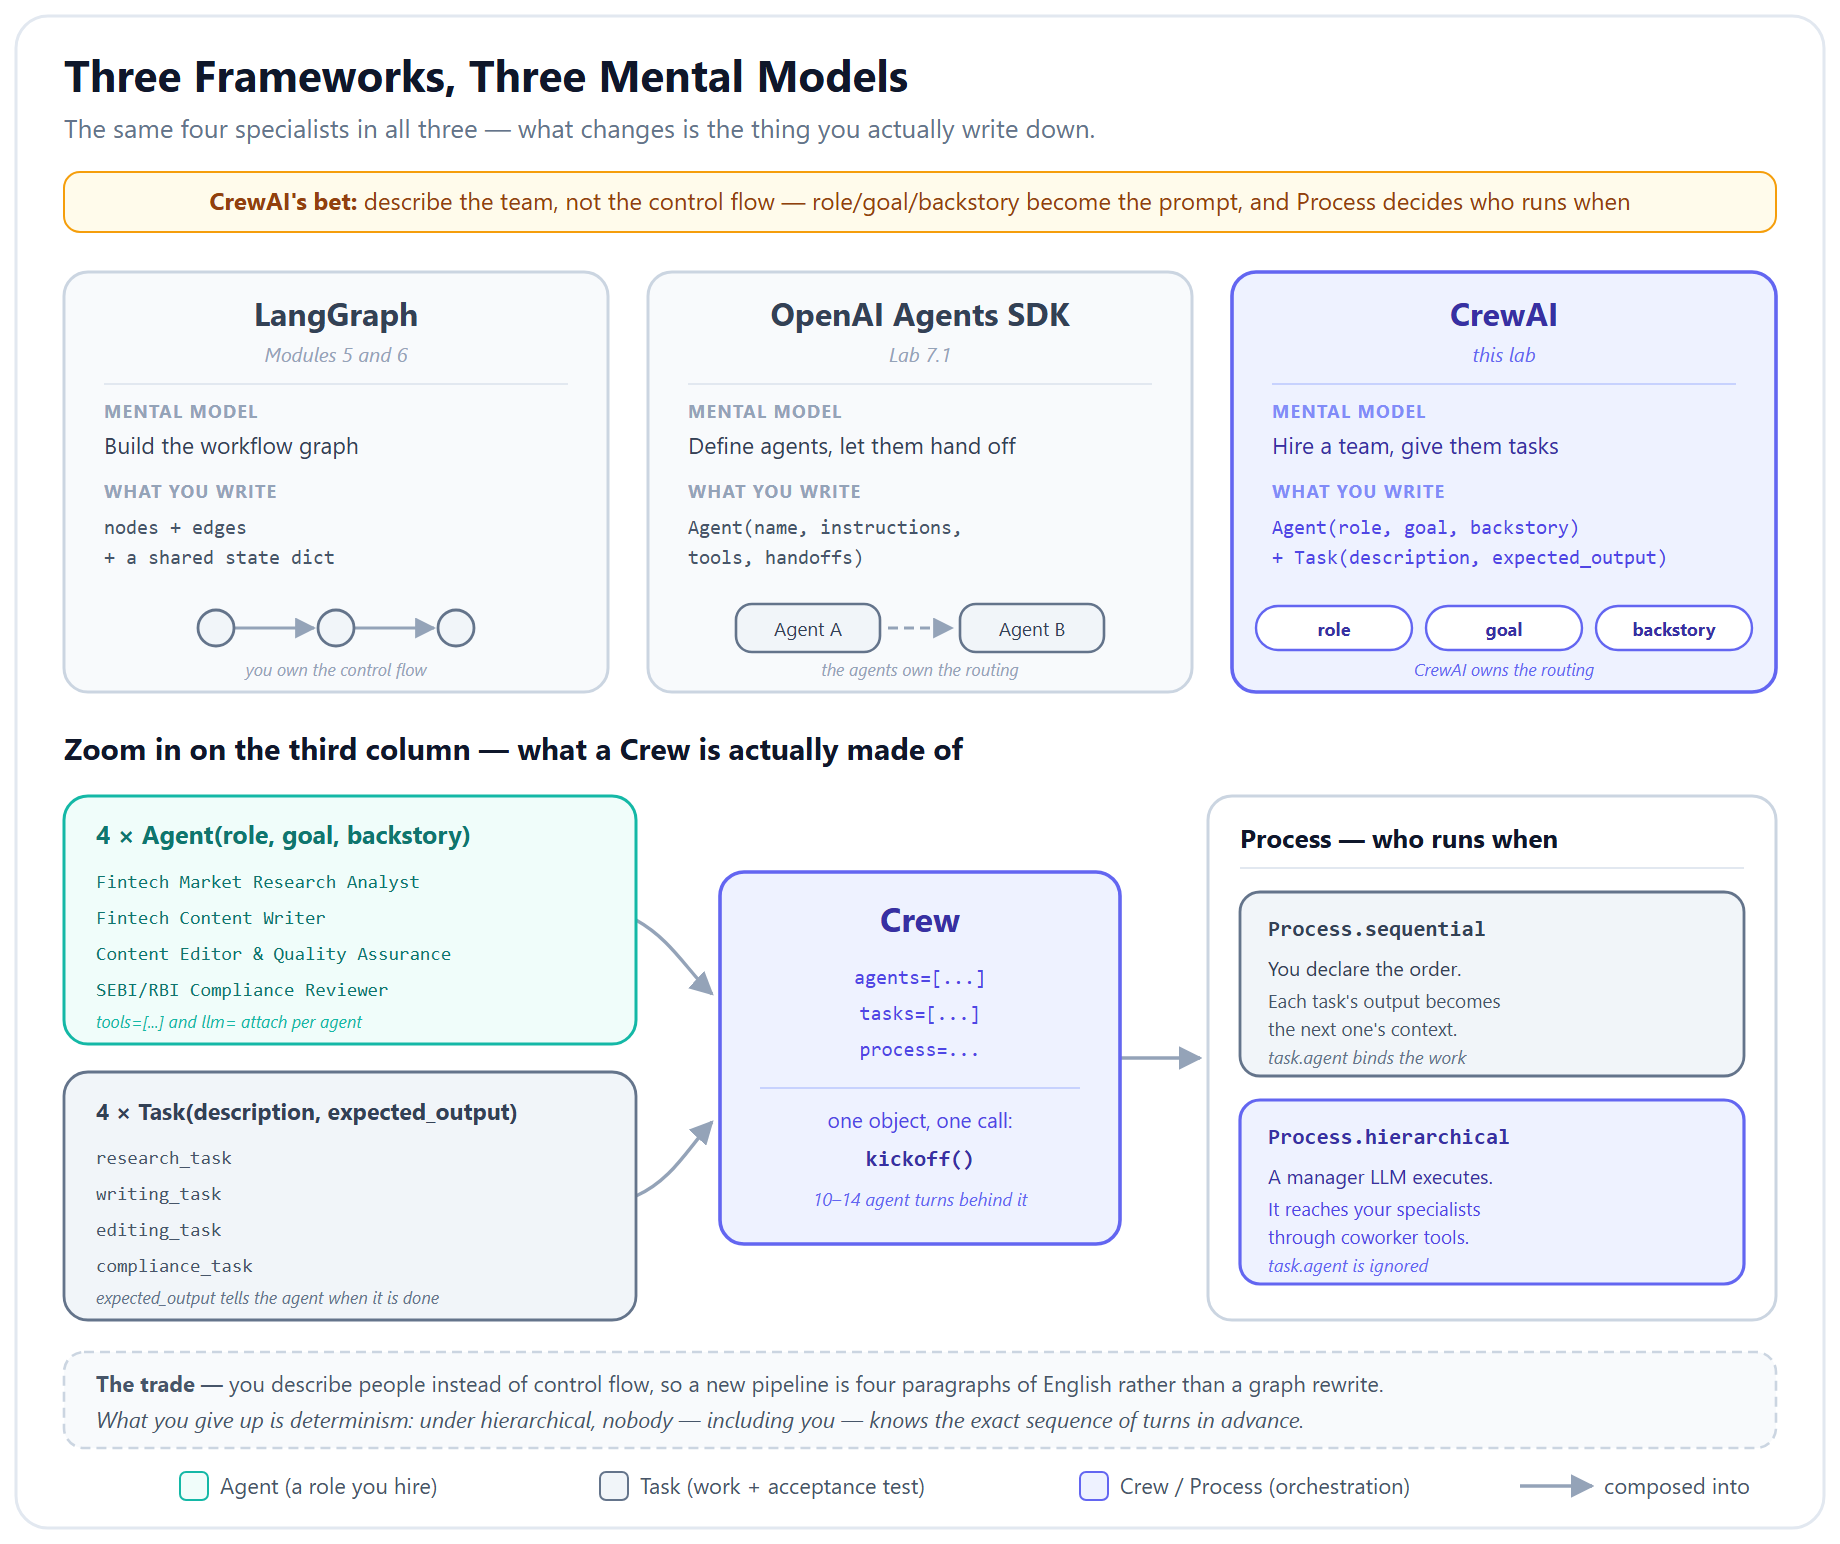

**Figure — Three frameworks, three mental models.** LangGraph gives you nodes, edges and a state dict; the OpenAI Agents SDK gives you agents that hand off; CrewAI gives you `Agent(role, goal, backstory)` objects plus explicit `Task(description, expected_output)` objects, assembled into a `Crew` whose `Process` decides who runs when.

## 6. Fintech Content Data

Inline data for BrightFin Media — content briefs, brand guidelines, compliance rules, and platform specs. All synthetic.


In [6]:
# --- BrightFin Media: Inline Fintech Content Data ---

# Content briefs (what clients want published)
CONTENT_BRIEFS = [
    {
        "brief_id": "BF-001",
        "client": "PayRight (UPI Payments)",
        "topic": "UPI transactions crossing 15 billion/month milestone",
        "platform": "LinkedIn",
        "tone": "Professional, data-driven",
        "key_points": ["15B monthly transactions", "40% YoY growth", "India leading global real-time payments"],
        "cta": "Learn how PayRight processes 2M+ daily transactions"
    },
    {
        "brief_id": "BF-002",
        "client": "WealthFirst (Mutual Funds)",
        "topic": "SIP investments reaching all-time high of \u20b923,000 crore/month",
        "platform": "Twitter",
        "tone": "Conversational, engaging",
        "key_points": ["\u20b923K crore monthly SIP", "7.8 crore SIP accounts", "Power of rupee-cost averaging"],
        "cta": "Start your SIP journey with WealthFirst"
    },
    {
        "brief_id": "BF-003",
        "client": "SecureLend (Digital Lending)",
        "topic": "RBI's new digital lending guidelines and what they mean for borrowers",
        "platform": "LinkedIn",
        "tone": "Educational, authoritative",
        "key_points": ["Mandatory disclosure of all charges", "Cooling-off period for borrowers", "Data privacy requirements"],
        "cta": "SecureLend is 100% RBI-compliant. Check your eligibility."
    },
]

# Brand guidelines
BRAND_GUIDELINES = {
    "voice": "Confident, knowledgeable, approachable. Never condescending.",
    "forbidden_words": ["guaranteed returns", "risk-free", "100% safe", "get rich", "double your money"],
    "required_elements": ["SEBI/RBI disclaimer where applicable", "Data source attribution", "Client CTA"],
    "hashtag_rules": "Max 5 hashtags. Always include #Fintech #India. Platform-specific otherwise."
}

# Compliance rules (SEBI/RBI)
COMPLIANCE_RULES = {
    "mutual_funds": "Must include: 'Mutual fund investments are subject to market risks. Read all scheme-related documents carefully.'",
    "lending": "Must include: 'Terms and conditions apply. Loans subject to creditworthiness assessment.'",
    "payments": "No disclaimer required for factual payment statistics.",
    "general": "Never promise specific returns. Always attribute data sources. Include 'Past performance does not guarantee future results' for investment content."
}

# Platform specifications
PLATFORM_SPECS = {
    "LinkedIn": {"max_chars": 3000, "hashtags": 5, "tone": "Professional", "format": "Long-form with bullets"},
    "Twitter": {"max_chars": 280, "hashtags": 3, "tone": "Punchy", "format": "Thread-friendly, hook first"},
    "Instagram": {"max_chars": 2200, "hashtags": 15, "tone": "Visual, storytelling", "format": "Carousel-friendly"}
}

# Simulated market trends (what the research tool returns)
MARKET_TRENDS = {
    "UPI": ["UPI 3.0 features launching Q2 2026", "International UPI corridors expanding to 12 countries", "UPI Lite crosses 10M daily transactions"],
    "mutual_funds": ["SEBI simplifying KYC for mutual fund investments", "Passive index funds AUM crosses \u20b910 lakh crore", "NFO launches up 35% in 2026"],
    "digital_lending": ["RBI tightening FLDG norms for fintechs", "Digital lending market projected at $720B by 2030", "Co-lending partnerships growing 45% YoY"]
}

print(f"Data loaded: {len(CONTENT_BRIEFS)} briefs, {len(PLATFORM_SPECS)} platforms")
print(f"Sample brief: {CONTENT_BRIEFS[0]['client']} - {CONTENT_BRIEFS[0]['topic'][:50]}...")

Data loaded: 3 briefs, 3 platforms
Sample brief: PayRight (UPI Payments) - UPI transactions crossing 15 billion/month milesto...


## 7. Define Content-Pipeline Tools

CrewAI uses the `@tool` decorator (the same idea as LangChain's `@tool`). We define three tools that each agent can call:

1. `search_market_trends` — get latest fintech trends for a topic (simulated).
2. `check_compliance` — verify content meets SEBI/RBI guidelines.
3. `format_for_platform` — adapt content for a specific social platform.


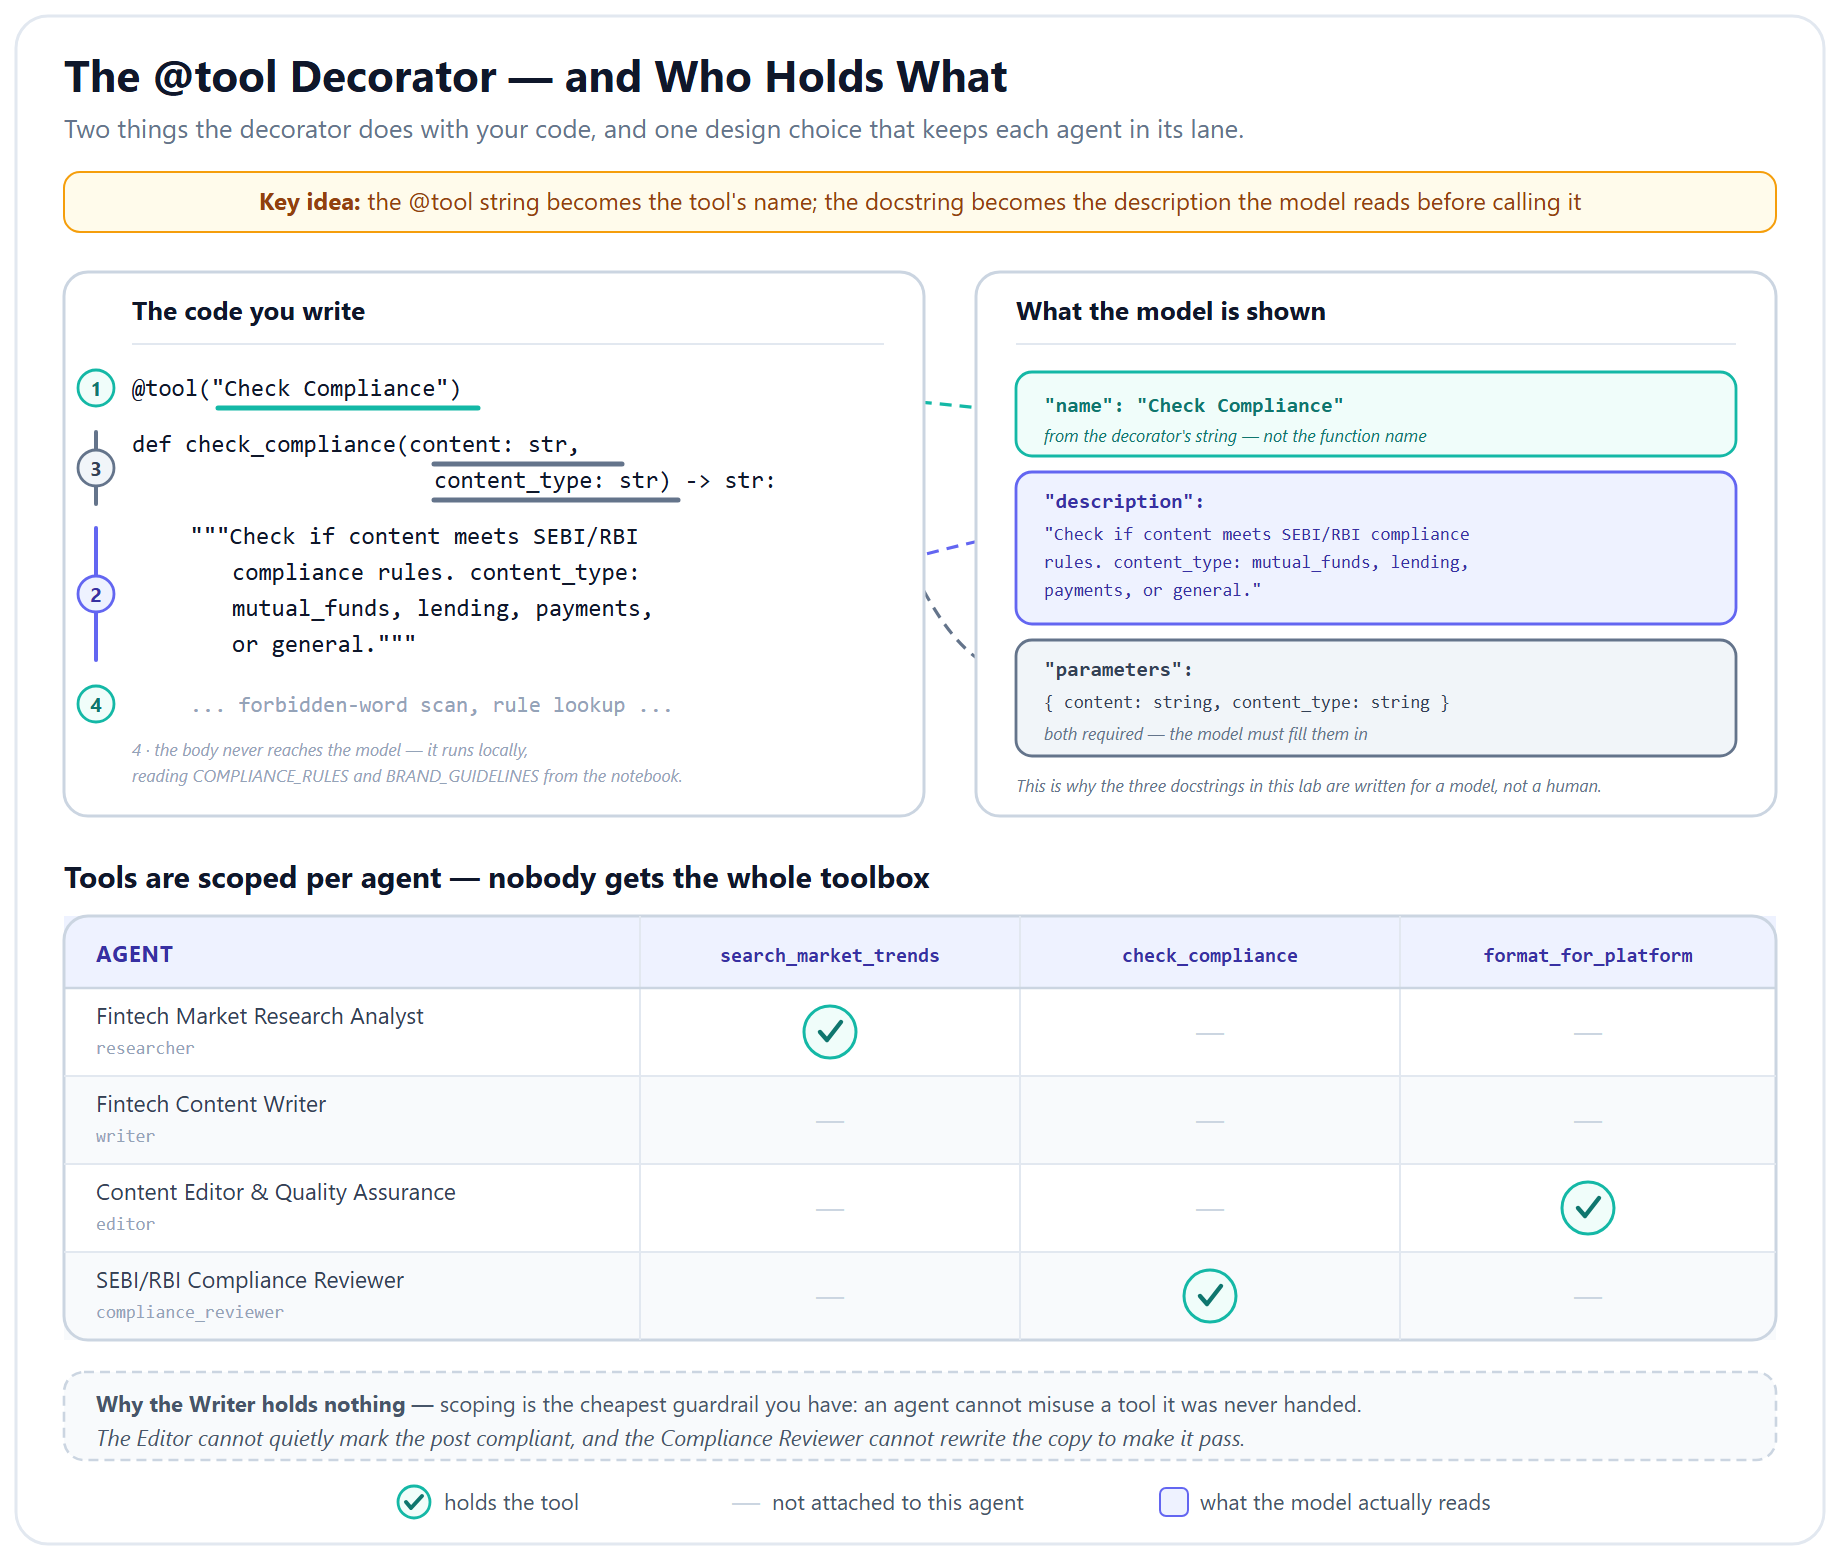

**Figure — `@tool` and who holds what.** The decorator's string argument becomes the tool's display name and the function's *docstring* becomes the description the LLM reads when deciding to call it — which is why the three docstrings here are written for a model, not a human. Tools are scoped per agent: Researcher holds `search_market_trends`, Editor holds `format_for_platform`, Compliance holds `check_compliance`, and the Writer holds none.

In [7]:
# --- Tool 1: Market Trends ---
@tool("Search Market Trends")
def search_market_trends(topic: str) -> str:
    """Search for the latest fintech market trends related to a topic. Returns 3 trending insights."""
    topic_lower = topic.lower()
    for trend_category, trend_list in MARKET_TRENDS.items():
        if trend_category.lower() in topic_lower or topic_lower in trend_category.lower():
            return (f"Trending insights for '{topic}':\n"
                    + "\n".join(f"  - {trend}" for trend in trend_list))
    return f"No specific trends found for '{topic}'. General fintech trends: Digital payments growing 28% YoY, embedded finance adoption accelerating."


# --- Tool 2: Compliance Check ---
@tool("Check Compliance")
def check_compliance(content: str, content_type: str) -> str:
    """Check if content meets SEBI/RBI compliance rules. content_type: mutual_funds, lending, payments, or general."""
    compliance_rule = COMPLIANCE_RULES.get(content_type.lower(), COMPLIANCE_RULES["general"])
    # Check for forbidden words
    violations = [forbidden_word for forbidden_word in BRAND_GUIDELINES["forbidden_words"]
                  if forbidden_word.lower() in content.lower()]
    if violations:
        return (f"COMPLIANCE VIOLATION: Contains forbidden words: {violations}\n"
                f"Required disclaimer: {compliance_rule}")
    # Check for required disclaimer
    has_disclaimer = any(phrase in content.lower() for phrase in
                         ["subject to market risks", "terms and conditions", "past performance"])
    if content_type in ["mutual_funds", "lending"] and not has_disclaimer:
        return f"COMPLIANCE WARNING: Missing required disclaimer.\nAdd: {compliance_rule}"
    return f"COMPLIANCE PASSED. Applicable rule: {compliance_rule}"


# --- Tool 3: Platform Formatter ---
@tool("Format for Platform")
def format_for_platform(content: str, platform: str) -> str:
    """Format content for a specific social media platform (LinkedIn, Twitter, or Instagram)."""
    platform_spec = PLATFORM_SPECS.get(platform)
    if not platform_spec:
        return f"Unknown platform '{platform}'. Supported: LinkedIn, Twitter, Instagram"
    character_count = len(content)
    length_status = ("WITHIN LIMIT" if character_count <= platform_spec["max_chars"]
                     else f"OVER LIMIT by {character_count - platform_spec['max_chars']} chars")
    return (
        f"Platform: {platform}\n"
        f"Character count: {character_count}/{platform_spec['max_chars']} ({length_status})\n"
        f"Recommended tone: {platform_spec['tone']}\n"
        f"Format: {platform_spec['format']}\n"
        f"Max hashtags: {platform_spec['hashtags']}"
    )


print("3 tools defined: search_market_trends, check_compliance, format_for_platform")

3 tools defined: search_market_trends, check_compliance, format_for_platform


In [8]:
# --- Test Tools ---
print("TEST: search_market_trends")
print(search_market_trends.run("UPI payments"))

print("\nTEST: check_compliance (should warn about missing disclaimer)")
print(check_compliance.run(content="SIP is the best way to invest. Start today!", content_type="mutual_funds"))

print("\nTEST: format_for_platform")
print(format_for_platform.run(content="A" * 300, platform="Twitter"))

TEST: search_market_trends
Trending insights for 'UPI payments':
  - UPI 3.0 features launching Q2 2026
  - International UPI corridors expanding to 12 countries
  - UPI Lite crosses 10M daily transactions

TEST: check_compliance (should warn about missing disclaimer)
COMPLIANCE WARNING: Missing required disclaimer.
Add: Must include: 'Mutual fund investments are subject to market risks. Read all scheme-related documents carefully.'

TEST: format_for_platform
Platform: Twitter
Character count: 300/280 (OVER LIMIT by 20 chars)
Recommended tone: Punchy
Format: Thread-friendly, hook first
Max hashtags: 3


## 8. Create the BrightFin Media Agents

Each agent has a **`role`** (job title), **`goal`** (what they're trying to achieve), and **`backstory`** (context that shapes their behaviour and tone). Tools are attached per-agent — only the Researcher needs `search_market_trends`, only the Editor needs `format_for_platform`, only the Compliance Reviewer needs `check_compliance`.


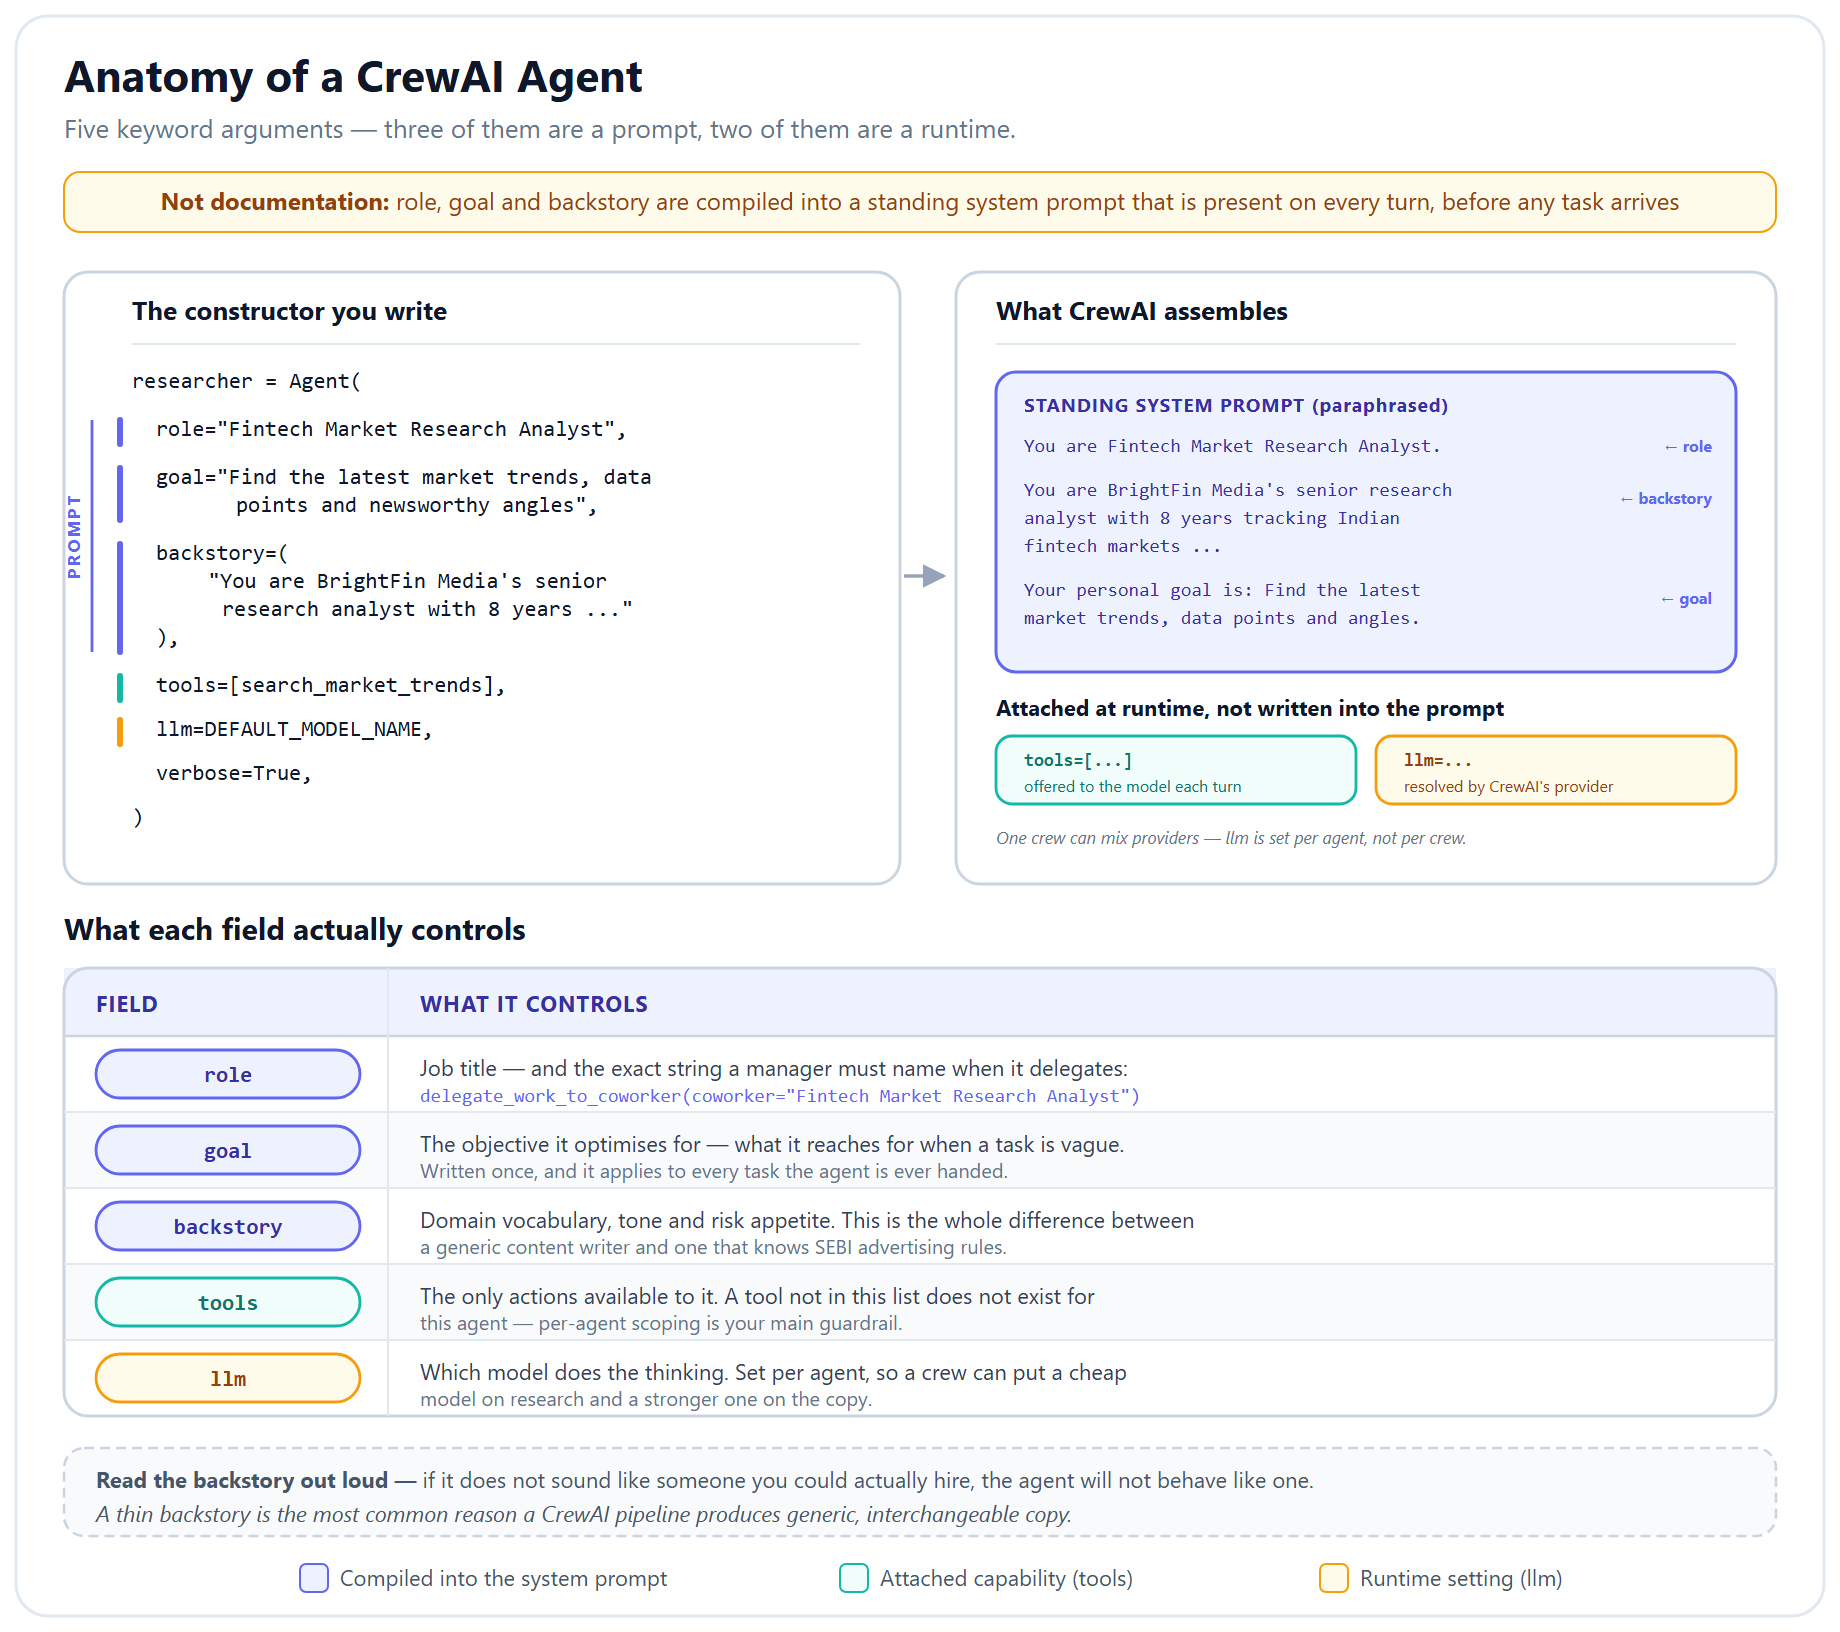

**Figure — Anatomy of a CrewAI agent.** `role` is the job title, `goal` is the KRA, `backstory` is the domain expertise — CrewAI compiles all three into a standing system prompt that shapes tone and risk appetite before any task arrives, then attaches `tools` and the `llm` on top.

In [9]:
# --- Agent 1: Market Researcher ---
researcher = Agent(
    role="Fintech Market Research Analyst",
    goal="Find the latest market trends, data points, and newsworthy angles for fintech content briefs",
    backstory=(
        "You are BrightFin Media's senior research analyst with 8 years of experience "
        "tracking Indian fintech markets. You follow NPCI, SEBI, and RBI announcements daily. "
        "You know the UPI ecosystem, mutual fund industry, and digital lending space inside out. "
        "Your research briefs are data-rich and always include specific numbers."
    ),
    tools=[search_market_trends],
    llm=DEFAULT_MODEL_NAME,
    verbose=True,
)

print(f"Agent: {researcher.role}")
print(f"  Tools: {[tool_object.name for tool_object in researcher.tools]}")

Agent: Fintech Market Research Analyst
  Tools: ['Search Market Trends']


In [10]:
# --- Agent 2: Content Writer ---
writer = Agent(
    role="Fintech Content Writer",
    goal="Create engaging, platform-optimized social media content that educates and converts",
    backstory=(
        "You are BrightFin Media's lead content writer, specializing in making complex "
        "financial topics accessible to everyday Indians. You write for LinkedIn, Twitter, "
        "and Instagram. Your content balances educational value with strong CTAs. "
        "You never use jargon without explaining it and always write in an approachable tone."
    ),
    llm=DEFAULT_MODEL_NAME,
    verbose=True,
)

print(f"Agent: {writer.role}")

Agent: Fintech Content Writer


In [11]:
# --- Agent 3: Editor ---
editor = Agent(
    role="Content Editor & Quality Assurance",
    goal="Ensure content meets brand guidelines, platform specs, and editorial standards",
    backstory=(
        "You are BrightFin Media's chief editor with a keen eye for quality. "
        "You enforce brand voice consistency, check character limits, verify data accuracy, "
        "and ensure every post follows platform best practices. You're especially strict about "
        "the forbidden words list and hashtag guidelines."
    ),
    tools=[format_for_platform],
    llm=DEFAULT_MODEL_NAME,
    verbose=True,
)

print(f"Agent: {editor.role}")

Agent: Content Editor & Quality Assurance


In [12]:
# --- Agent 4: Compliance Reviewer ---
compliance_reviewer = Agent(
    role="SEBI/RBI Compliance Reviewer",
    goal="Ensure all fintech content complies with SEBI and RBI regulations",
    backstory=(
        "You are BrightFin Media's compliance specialist with deep knowledge of "
        "SEBI's advertising guidelines for mutual funds, RBI's digital lending norms, "
        "and general financial services advertising regulations in India. "
        "You flag any content that could mislead investors or violate regulatory norms. "
        "You add required disclaimers and remove forbidden claims."
    ),
    tools=[check_compliance],
    llm=DEFAULT_MODEL_NAME,
    verbose=True,
)

print(f"Agent: {compliance_reviewer.role}")

Agent: SEBI/RBI Compliance Reviewer


## 9. Define Tasks for the Content Pipeline

Each `Task` says **what** needs to be done, **who** does it, and **what good output looks like**. In `Process.sequential`, each task's output is automatically threaded into the next task as context.


In [13]:
# --- Select a content brief for processing ---
content_brief = CONTENT_BRIEFS[0]  # UPI post for LinkedIn
print(f"Processing brief: {content_brief['brief_id']} - {content_brief['client']}")
print(f"Topic: {content_brief['topic']}")
print(f"Platform: {content_brief['platform']} | Tone: {content_brief['tone']}")

# --- Task 1: Research ---
research_task = Task(
    description=(
        f"Research the latest trends and data points about: {content_brief['topic']}\n"
        f"Key points to cover: {', '.join(content_brief['key_points'])}\n"
        f"Use the search_market_trends tool to find current trends.\n"
        f"Provide a research brief with 5-7 data points and trend insights."
    ),
    agent=researcher,
    expected_output="A research brief with 5-7 data points, trend insights, and suggested angles for the content.",
)

# --- Task 2: Write ---
writing_task = Task(
    description=(
        f"Write a {content_brief['platform']} post about: {content_brief['topic']}\n"
        f"Tone: {content_brief['tone']}\n"
        f"CTA: {content_brief['cta']}\n"
        f"Use the research brief from the previous task as your data source.\n"
        f"Brand voice: {BRAND_GUIDELINES['voice']}\n"
        f"Forbidden words: {', '.join(BRAND_GUIDELINES['forbidden_words'])}"
    ),
    agent=writer,
    expected_output=f"A complete {content_brief['platform']} post ready for editorial review.",
)

# --- Task 3: Edit ---
editing_task = Task(
    description=(
        f"Review and edit the {content_brief['platform']} post for quality:\n"
        f"1. Check character count (max {PLATFORM_SPECS[content_brief['platform']]['max_chars']})\n"
        f"2. Verify brand voice consistency\n"
        f"3. Ensure hashtags follow guidelines (max {PLATFORM_SPECS[content_brief['platform']]['hashtags']})\n"
        f"4. Use the format_for_platform tool to validate formatting\n"
        f"5. Polish the writing for maximum engagement"
    ),
    agent=editor,
    expected_output="An edited, polished post that meets all platform and brand guidelines.",
)

# --- Task 4: Compliance ---
content_type = "payments"  # UPI content
compliance_task = Task(
    description=(
        f"Review the post for SEBI/RBI compliance:\n"
        f"Content type: {content_type}\n"
        f"1. Use the check_compliance tool to verify regulatory compliance\n"
        f"2. Check for forbidden claims (guaranteed returns, risk-free, etc.)\n"
        f"3. Add required disclaimers if needed\n"
        f"4. Verify data source attributions are present\n"
        f"Compliance rules: {COMPLIANCE_RULES.get(content_type, COMPLIANCE_RULES['general'])}"
    ),
    agent=compliance_reviewer,
    expected_output="Final compliance-approved post with all required disclaimers and a compliance status report.",
)

print("4 tasks defined: research -> writing -> editing -> compliance")

Processing brief: BF-001 - PayRight (UPI Payments)
Topic: UPI transactions crossing 15 billion/month milestone
Platform: LinkedIn | Tone: Professional, data-driven
4 tasks defined: research -> writing -> editing -> compliance


In [14]:
# Print task summaries
for position, task in enumerate([research_task, writing_task, editing_task, compliance_task], 1):
    print(f"Task {position}: {task.agent.role}")
    print(f"  Expected: {task.expected_output[:80]}...")
    print()

Task 1: Fintech Market Research Analyst
  Expected: A research brief with 5-7 data points, trend insights, and suggested angles for ...

Task 2: Fintech Content Writer
  Expected: A complete LinkedIn post ready for editorial review....

Task 3: Content Editor & Quality Assurance
  Expected: An edited, polished post that meets all platform and brand guidelines....

Task 4: SEBI/RBI Compliance Reviewer
  Expected: Final compliance-approved post with all required disclaimers and a compliance st...



## 10. Part 1 — Sequential Content Pipeline

In `Process.sequential`, tasks execute in declared order. This mirrors BrightFin's *current* email workflow exactly: Researcher → Writer → Editor → Compliance. The win is throughput and consistency, not creative re-routing.


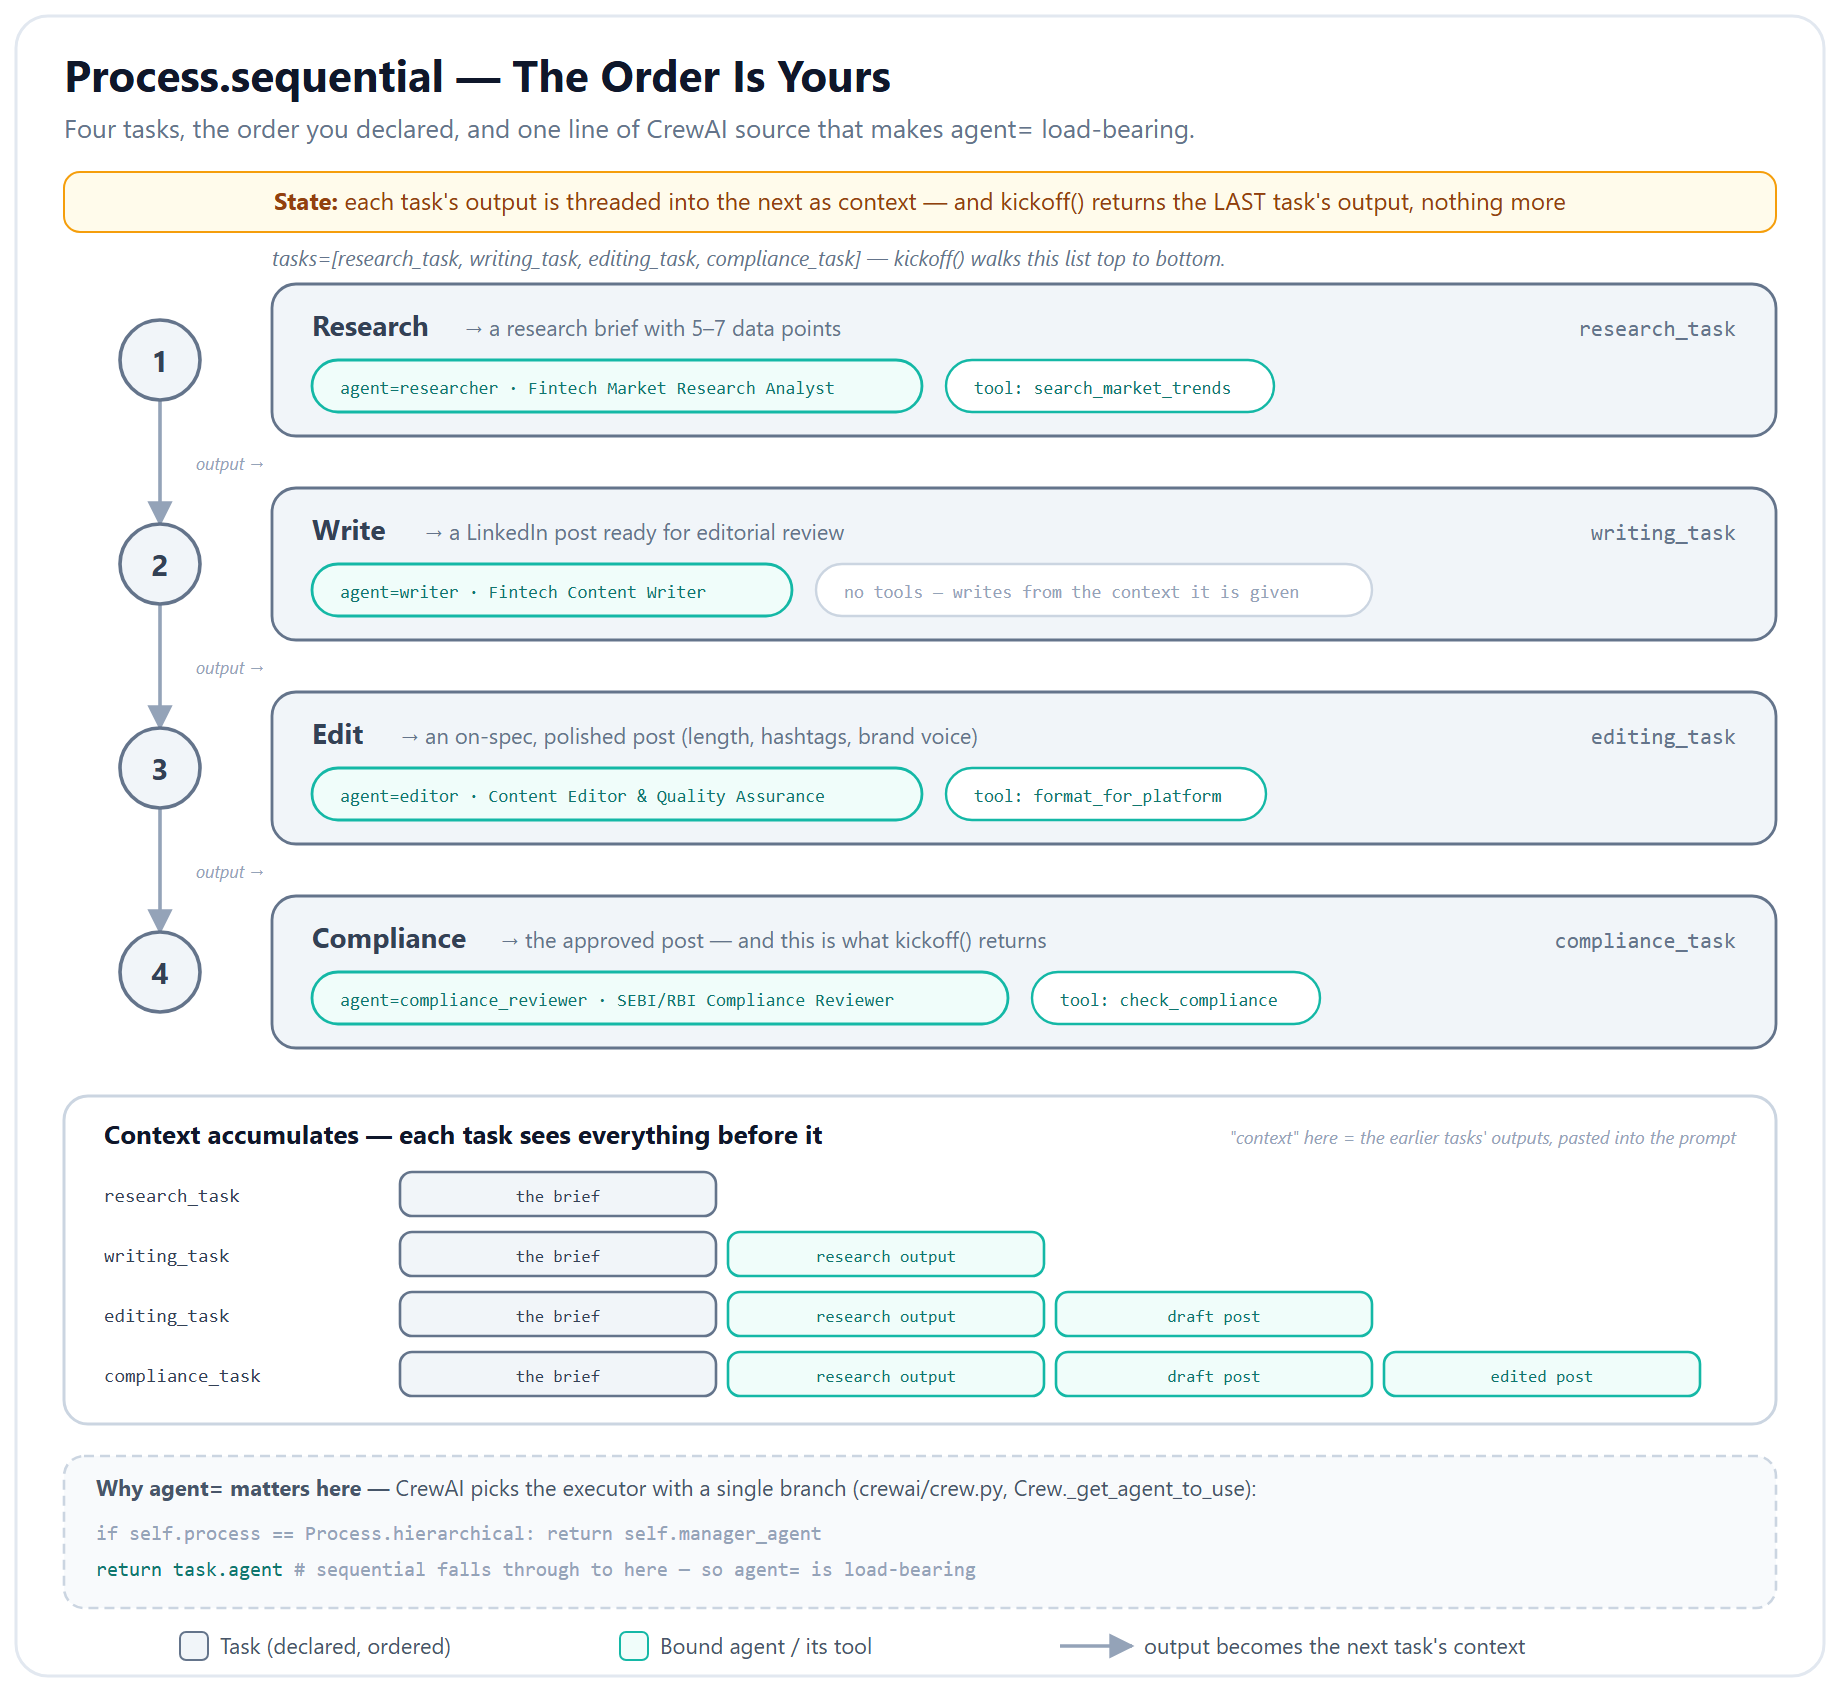

**Figure — `Process.sequential`: the order is yours.** Tasks fire in declared order and each task's output is threaded into the next as context — Research → Write → Edit → Compliance, BrightFin's current email chain with the latency removed. Here `agent=` on each `Task` is what binds the work to a specialist.

In [15]:
# --- Sequential Crew ---
sequential_crew = Crew(
    agents=[researcher, writer, editor, compliance_reviewer],
    tasks=[research_task, writing_task, editing_task, compliance_task],
    process=Process.sequential,
    verbose=True,
)

print("Sequential Crew assembled!")
print(f"  Agents: {[crew_agent.role for crew_agent in sequential_crew.agents]}")
print(f"  Process: Sequential (fixed order)")
print("\nKicking off the pipeline...")
print("=" * 60)

sequential_result = await sequential_crew.kickoff_async()

print("\n" + "=" * 60)
print("SEQUENTIAL PIPELINE RESULT:")
print(sequential_result)

Sequential Crew assembled!
  Agents: ['Fintech Market Research Analyst', 'Fintech Content Writer', 'Content Editor & Quality Assurance', 'SEBI/RBI Compliance Reviewer']
  Process: Sequential (fixed order)

Kicking off the pipeline...


╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 2490789b-aba1-4231-92c2-7fcd4119a33b                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Research the latest trends and data points about: UPI transactions crossing 15 billion/month milestone   │
│  Key points to cover: 15B monthly transactions, 40% YoY growth, India leading global real-time payments         │
│  Use the search_market_trends tool to find current trends.                                                      │
│  Provide a research brief with 5-7 data points and trend insights.                                              │
│  ID: 93628a97-18ea-476f-ade2-a2ed3fe4cd50                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Fintech Market Research Analyst                                                                         │
│                                                                                                                 │
│  Task: Research the latest trends and data points about: UPI transactions crossing 15 billion/month milestone   │
│  Key points to cover: 15B monthly transactions, 40% YoY growth, India leading global real-time payments         │
│  Use the search_market_trends tool to find current trends.                                                      │
│  Provide a research brief with 5-7 data points and trend insights.                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#1) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: search_market_trends                                                                                     │
│  Args: {'topic': 'UPI transactions crossing 15 billion per month'}                                              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: SEBI/RBI Compliance Reviewer                                                                            │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  How India’s UPI Crossed 15 Billion Monthly Transactions: A Payment Revolution in Action                        │
│                                                                                                                 │
│  In 2024, India’s Unified Payments Interface (UPI) achieved a remarkable milestone—over 15 billion              │
│  transactions in a single month. This surge reflects more than just numbers; it signals growing trust and       │
│  reliance on digital payments by everyday consumers and merchants nationwide.                                   │
│                                                                                                                 │
│  Key factors fueling this growth include:                                                                       │
│  • A staggering 40% year-on-year increase in UPI transactions during 2023-24                                    │
│  • Higher smartphone penetration coupled with rising digital literacy                                           │
│  • Expanded merchant onboarding bringing more businesses into the digital fold                                  │
│                                                                                                                 │
│  India now leads the world in real-time payment volumes, surpassing major markets like China, the USA, and      │
│  Europe. Looking ahead, the upcoming UPI 3.0 launch promises enhanced features such as auto-fetch merchant      │
│  onboarding, increased transaction limits, and richer payment data—further strengthening this digital payments  │
│  ecosystem.                                                                                                     │
│                                                                                                                 │
│  At PayRight, we process over 2 million transactions every day, leveraging the robust UPI infrastructure to     │
│  empower seamless, secure, and real-time payments for our partners and customers.                               │
│                                                                                                                 │
│  Curious about how we handle this massive transaction volume with speed and reliability?                        │
│                                                                                                                 │
│  👉 Learn how PayRight powers millions of daily transactions and supports India’s digital payment revolution:   │
│  [Insert Link]                                                                                                  │
│                                                                                                                 │
│  #UPI #DigitalPayments #Fintech #FinancialInclusion #PayRight #IndiaPayments #UPI3 #RealTimePayments            │
│                                                                                                                 │
│  Compliance Status Report:                                                                                      │
│  - The content complies with SEBI and RBI advertising guidelines for payments.                                  │
│  - No misleading or forbidden claims such as guaranteed returns or risk-free assertions are present.            │
│  - Data sources and statistics are factual and no discla

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Review the post for SEBI/RBI compliance:                                                                 │
│  Content type: payments                                                                                         │
│  1. Use the check_compliance tool to verify regulatory compliance                                               │
│  2. Check for forbidden claims (guaranteed returns, risk-free, etc.)                                            │
│  3. Add required disclaimers if needed                                                                          │
│  4. Verify data source attributions are present                                                                 │
│  Compliance rules: No disclaimer required for factual payment statistics.                                       │
│  Agent: SEBI/RBI Compliance Reviewer                                                                            │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


SEQUENTIAL PIPELINE RESULT:
How India’s UPI Crossed 15 Billion Monthly Transactions: A Payment Revolution in Action

In 2024, India’s Unified Payments Interface (UPI) achieved a remarkable milestone—over 15 billion transactions in a single month. This surge reflects more than just numbers; it signals growing trust and reliance on digital payments by everyday consumers and merchants nationwide.

Key factors fueling this growth include:
• A staggering 40% year-on-year increase in UPI transactions during 2023-24
• Higher smartphone penetration coupled with rising digital literacy
• Expanded merchant onboarding bringing more businesses into the digital fold

India now leads the world in real-time payment volumes, surpassing major markets like China, the USA, and Europe. Looking ahead, the upcoming UPI 3.0 launch promises enhanced features such as auto-fetch merchant onboarding, increased transaction limits, and richer payment data—further strengthening this digital payments ecosystem.

At

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 2490789b-aba1-4231-92c2-7fcd4119a33b                                                                       │
│  Final Output: How India’s UPI Crossed 15 Billion Monthly Transactions: A Payment Revolution in Action          │
│                                                                                                                 │
│  In 2024, India’s Unified Payments Interface (UPI) achieved a remarkable milestone—over 15 billion              │
│  transactions in a single month. This surge reflects more than just numbers; it signals growing trust and       │
│  reliance on digital payments by everyday consumers and merchants nationwide.                                   │
│                                                                                                                 │
│  Key factors fueling this growth include:                                                                       │
│  • A staggering 40% year-on-year increase in UPI transactions during 2023-24                                    │
│  • Higher smartphone penetration coupled with rising digital literacy                                           │
│  • Expanded merchant onboarding bringing more businesses into the digital fold                                  │
│                                                                                                                 │
│  India now leads the world in real-time payment volumes, surpassing major markets like China, the USA, and      │
│  Europe. Looking ahead, the upcoming UPI 3.0 launch promises enhanced features such as auto-fetch merchant      │
│  onboarding, increased transaction limits, and richer payment data—further strengthening this digital payments  │
│  ecosystem.                                                                                                     │
│                                                                                                                 │
│  At PayRight, we process over 2 million transactions every day, leveraging the robust UPI infrastructure to     │
│  empower seamless, secure, and real-time payments for our partners and customers.                               │
│                                                                                                                 │
│  Curious about how we handle this massive transaction volume with speed and reliability?                        │
│                                                                                                                 │
│  👉 Learn how PayRight powers millions of daily transactions and supports India’s digital payment revolution:   │
│  [Insert Link]                                                                                                  │
│                                                                                                                 │
│  #UPI #DigitalPayments #Fintech #FinancialInclusion #PayRight #IndiaPayments #UPI3 #RealTimePayments            │
│                                                                                                                 │
│  Compliance Status Report:                                                                                      │
│  - The content complies with SEBI and RBI advertising guidelines for payments.                                  │
│  - No misleading or forbidden claims such as guaranteed returns or risk-free assertions are present.            │
│  - Data sources and statistics are factual and no discl

In [16]:
# --- Analyze Sequential Pipeline ---
print("Sequential Pipeline Analysis")
print("=" * 60)
print(f"Brief: {content_brief['brief_id']} - {content_brief['client']}")
print(f"Platform: {content_brief['platform']}")
print(f"\nFinal output length: {len(str(sequential_result))} chars")
print(f"Pipeline flow: Researcher -> Writer -> Editor -> Compliance")
print(f"\nKey observation: Each agent built on the previous agent's output.")

Sequential Pipeline Analysis
Brief: BF-001 - PayRight (UPI Payments)
Platform: LinkedIn

Final output length: 1920 chars
Pipeline flow: Researcher -> Writer -> Editor -> Compliance

Key observation: Each agent built on the previous agent's output.


## 11. Part 2 — Hierarchical Pipeline with a Manager Agent

In `Process.hierarchical`, CrewAI auto-creates a **manager agent** from `manager_llm`, and that manager becomes the executor of every task: it reads the task, decides which specialist should actually do the work, and delegates. Be precise about what this does and does not change — `Crew._run_hierarchical_process()` still iterates `self.tasks` in the order you declared them. What hierarchical changes is **who executes each task**, not the sequence they are attempted in.

Use this when the right *division of labour* varies by brief — the manager can consult the compliance reviewer early on a high-risk topic, or lean almost entirely on the researcher for breaking news, without you rewriting the task list.

> **Why the tasks below carry no `agent=`.** `Crew._get_agent_to_use()` returns `self.manager_agent` for *every* task whenever `process` is hierarchical, and only falls back to `task.agent` under `Process.sequential`. A task-level `agent=` in a hierarchical crew is therefore dead code — it binds nothing. The specialists are still used, just indirectly: CrewAI auto-creates the manager with `allow_delegation=True` and hands it `delegate_work_to_coworker` / `ask_question_to_coworker` tools generated from `crew.agents`. Watch for those tool names in the verbose trace — they are the manager reaching for your four agents.

> **Expect some untidiness.** A manager LLM routinely mis-spells a coworker's role and gets back `Error executing tool. coworker mentioned not found, it must be one of the following options: …`. That is CrewAI correcting the manager mid-flight, not a bug in your code — and it is precisely the non-determinism you trade away when you choose `sequential`.


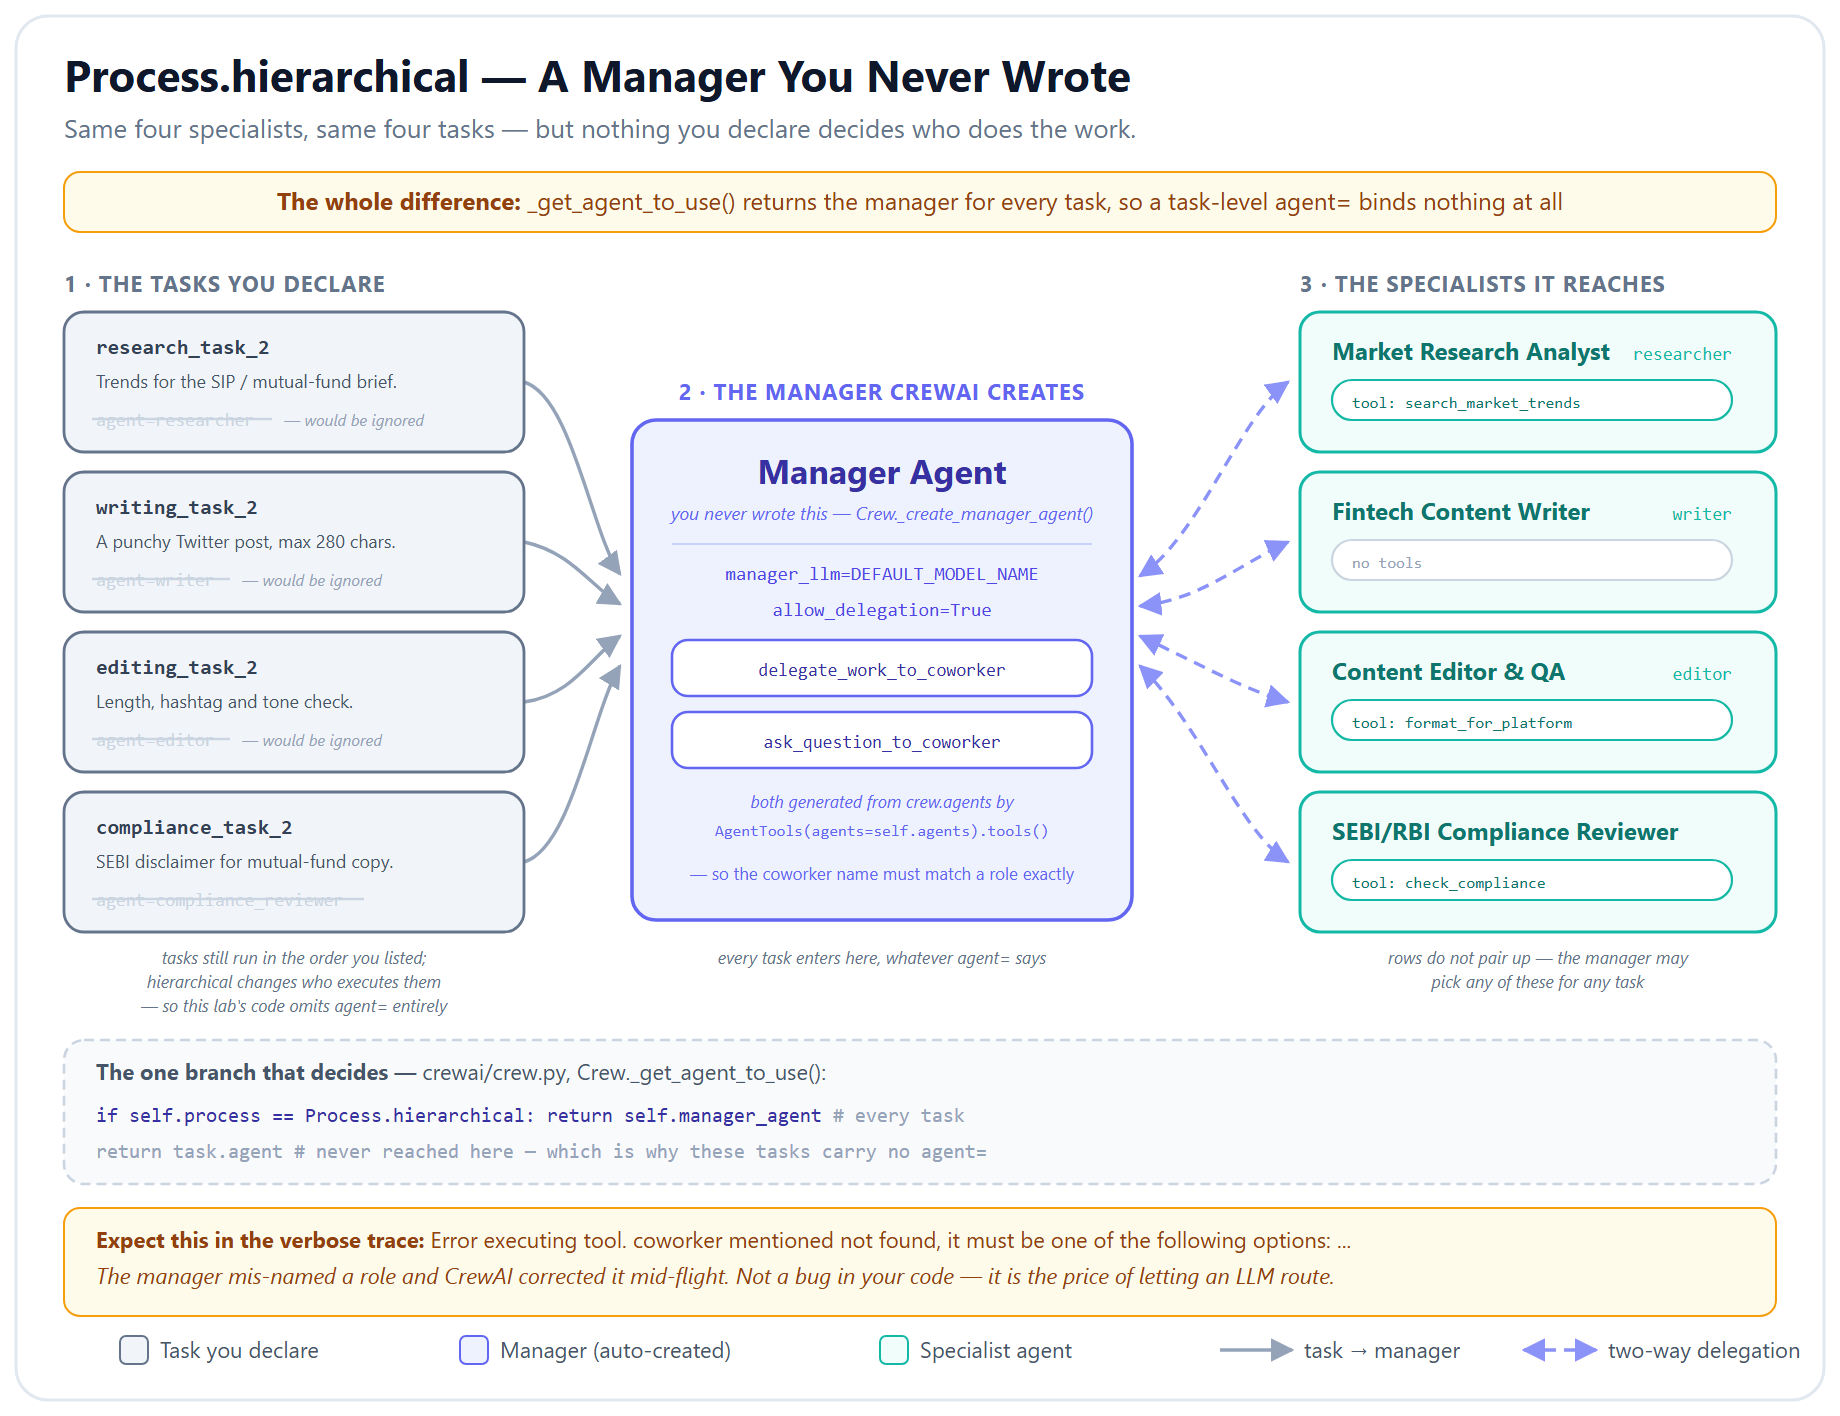

**Figure — `Process.hierarchical`: the executor is the manager.** CrewAI auto-creates a manager agent from `manager_llm`, arms it with `delegate_work_to_coworker` and `ask_question_to_coworker` built from `crew.agents`, and routes every task through it. Each task's own `agent=` is greyed out here because `_get_agent_to_use()` returns the manager whenever the process is hierarchical — the binding is inert.

In [17]:
# --- Use a different content brief for the hierarchical demo ---
second_brief = CONTENT_BRIEFS[1]  # SIP/Mutual Funds post for Twitter
print(f"Processing brief: {second_brief['brief_id']} - {second_brief['client']}")
print(f"Topic: {second_brief['topic']}")

# Redefine the four tasks for the second brief.
# NOTE the missing `agent=` — unlike Part 1, that is deliberate. Under Process.hierarchical,
# CrewAI resolves the executor like this (crewai/crew.py):
#
#     def _get_agent_to_use(self, task):
#         if self.process == Process.hierarchical:
#             return self.manager_agent
#         return task.agent
#
# So a task-level executor binding is SILENTLY IGNORED here — writing one would be a lie in the
# source. The four specialists still do the work: Crew._create_manager_agent() gives the manager
# allow_delegation=True plus delegate_work_to_coworker / ask_question_to_coworker tools built
# from crew.agents, and the manager reaches them through those.
research_task_2 = Task(
    description=f"Research trends about: {second_brief['topic']}. Key points: {', '.join(second_brief['key_points'])}",
    expected_output="Research brief with data points about SIP and mutual fund trends.",
)

writing_task_2 = Task(
    description=f"Write a {second_brief['platform']} post. Topic: {second_brief['topic']}. Tone: {second_brief['tone']}. CTA: {second_brief['cta']}",
    expected_output=f"A complete {second_brief['platform']} post (max {PLATFORM_SPECS[second_brief['platform']]['max_chars']} chars).",
)

editing_task_2 = Task(
    description=f"Edit the {second_brief['platform']} post. Check: character count (max 280), hashtags (max 3), tone (punchy).",
    expected_output="Polished tweet ready for compliance review.",
)

compliance_task_2 = Task(
    description=f"Verify SEBI compliance for mutual fund content. Required disclaimer: {COMPLIANCE_RULES['mutual_funds']}",
    expected_output="Compliance-approved tweet with required SEBI disclaimer.",
)

# --- Hierarchical Crew ---
hierarchical_crew = Crew(
    agents=[researcher, writer, editor, compliance_reviewer],
    tasks=[research_task_2, writing_task_2, editing_task_2, compliance_task_2],
    process=Process.hierarchical,
    manager_llm=DEFAULT_MODEL_NAME,
    verbose=True,
)

print("\nHierarchical Crew assembled (manager will delegate)!")
print("=" * 60)

hierarchical_result = await hierarchical_crew.kickoff_async()

print("\n" + "=" * 60)
print("HIERARCHICAL PIPELINE RESULT:")
print(hierarchical_result)

Processing brief: BF-002 - WealthFirst (Mutual Funds)
Topic: SIP investments reaching all-time high of ₹23,000 crore/month

Hierarchical Crew assembled (manager will delegate)!


╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 13fe8697-faf2-4f27-a8c6-ba09b21080d3                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Research trends about: SIP investments reaching all-time high of ₹23,000 crore/month. Key points: ₹23K   │
│  crore monthly SIP, 7.8 crore SIP accounts, Power of rupee-cost averaging                                       │
│  ID: e5da79a8-6b1c-445a-8759-5495ed0afb3f                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Crew Manager                                                                                            │
│                                                                                                                 │
│  Task: Research trends about: SIP investments reaching all-time high of ₹23,000 crore/month. Key points: ₹23K   │
│  crore monthly SIP, 7.8 crore SIP accounts, Power of rupee-cost averaging                                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#1) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: delegate_work_to_coworker                                                                                │
│  Args: {'task': 'Research and gather detailed data points and current trends about SIP (Systematic Investment   │
│  Plan) investments in India, focusing on the fact that SIP investments have reached an all-time hi...           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Crew Manager                                                                                            │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  SIP investments in India hit a record ₹23,000 crore/month with 7.8 crore accounts! 🚀 Start small, stay        │
│  consistent, and grow wealth with rupee-cost averaging. Ready to begin? Kick off your SIP journey with          │
│  WealthFirst today! #InvestSmart #SIP #WealthFirst                                                              │
│                                                                                                                 │
│  Mutual fund investments are subject to market risks. Read all scheme-related documents carefully.              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Verify SEBI compliance for mutual fund content. Required disclaimer: Must include: 'Mutual fund          │
│  investments are subject to market risks. Read all scheme-related documents carefully.'                         │
│  Agent: Crew Manager                                                                                            │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


HIERARCHICAL PIPELINE RESULT:
SIP investments in India hit a record ₹23,000 crore/month with 7.8 crore accounts! 🚀 Start small, stay consistent, and grow wealth with rupee-cost averaging. Ready to begin? Kick off your SIP journey with WealthFirst today! #InvestSmart #SIP #WealthFirst

Mutual fund investments are subject to market risks. Read all scheme-related documents carefully.


╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 13fe8697-faf2-4f27-a8c6-ba09b21080d3                                                                       │
│  Final Output: SIP investments in India hit a record ₹23,000 crore/month with 7.8 crore accounts! 🚀 Start      │
│  small, stay consistent, and grow wealth with rupee-cost averaging. Ready to begin? Kick off your SIP journey   │
│  with WealthFirst today! #InvestSmart #SIP #WealthFirst                                                         │
│                                                                                                                 │
│  Mutual fund investments are subject to market risks. Read all scheme-related documents carefully.              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [18]:
# --- Compare Sequential vs Hierarchical ---
print("Sequential vs Hierarchical Comparison")
print("=" * 60)
print(f"\nSequential (LinkedIn post):")
print(f"  Flow: Fixed order (Research -> Write -> Edit -> Compliance)")
print(f"  Output length: {len(str(sequential_result))} chars")
print(f"  Control: You decide the order")

print(f"\nHierarchical (Twitter post):")
print(f"  Flow: Manager-delegated (manager decides order and assignments)")
print(f"  Output length: {len(str(hierarchical_result))} chars")
print(f"  Control: Manager LLM decides the order")

print(f"\nKey Difference:")
print(f"  Sequential = predictable, consistent (like a factory assembly line)")
print(f"  Hierarchical = flexible, adaptive (like a project manager delegating)")

Sequential vs Hierarchical Comparison

Sequential (LinkedIn post):
  Flow: Fixed order (Research -> Write -> Edit -> Compliance)
  Output length: 1920 chars
  Control: You decide the order

Hierarchical (Twitter post):
  Flow: Manager-delegated (manager decides order and assignments)
  Output length: 353 chars
  Control: Manager LLM decides the order

Key Difference:
  Sequential = predictable, consistent (like a factory assembly line)
  Hierarchical = flexible, adaptive (like a project manager delegating)


> ⏭️ **After the session.** This section is not run live in the workshop. Work through it afterwards, top to bottom.

## 12. Aside — CrewAI Flows: demoted in the docs, not deprecated in the code

Open the CrewAI documentation today and the first thing you meet is **Flows** — an event-driven layer
where you subclass `Flow`, mark an entry point with `@start()`, and chain steps with `@listen(...)` —
alongside JSONC-configured projects. The older `@CrewBase` class plus `agents.yaml` / `tasks.yaml`
layout is now labelled **"classic"**. The plain `Agent` / `Task` / `Crew` constructors this lab uses are
still documented, under **"Direct Code Definition"**, and carry **no deprecation marker anywhere in the
CrewAI source** — verified against `crewai` 1.15, where the only `deprecated=` markers near these
classes sit on individual fields we never touch (`Crew.function_calling_llm`, `Task.max_retries`).

State it precisely, and resist overstating it in either direction:

> **Demoted in the docs. Not deprecated in the code.**

| | What it is | Status |
|---|---|---|
| `Agent` / `Task` / `Crew` constructors | plain Python objects — what this lab uses | fully supported; documented under "Direct Code Definition" |
| `Flow` + `@start` / `@listen` | event-driven orchestration *around* crews | what the docs now lead with |
| `@CrewBase` + YAML config | decorator / config project layout | labelled "classic" — **this lab does not teach it** |

**Why this lab still teaches constructors.** Two practical reasons. First, a Flow is a *wrapper*:
`@start()` and `@listen()` decide **when** a crew runs and what passes between steps, but inside each
step you still build `Agent`, `Task` and `Crew` exactly as you did above — the constructors are the
foundation either way, so learning them is not a detour. Second, the documented way to start a Flow
project is the CLI scaffold `crewai create flow <name>`, which emits a **multi-file Python package**
(`main.py`, a `crews/` directory, `pyproject.toml`). A notebook cannot run that — there is no package
for it to scaffold into. What a notebook *can* do is show the shape, which is the next cell.

In [19]:
# The shape of a Flow, nothing more. No LLM calls and no cost: each step just returns a string.
# In a real project, step two would build and kick off a Crew exactly like the ones above.
from crewai.flow import Flow, listen, start


class ContentPipelineFlow(Flow):
    """The BrightFin pipeline expressed as a Flow instead of one sequential Crew."""

    @start()
    def pick_content_brief(self):
        """Entry point — chooses which brief the pipeline will process."""
        return CONTENT_BRIEFS[0]["topic"]

    @listen(pick_content_brief)
    def run_content_crew(self, topic):
        """Runs after pick_content_brief, receiving that step's return value as `topic`."""
        # The real version of this line: return sequential_crew.kickoff(inputs={"topic": topic})
        return f"[the crew would run here] topic = {topic}"


# Flow.kickoff() is notebook-safe: it detects an already-running asyncio loop (ipykernel / Colab)
# and offloads to a ThreadPoolExecutor instead of raising "asyncio.run() cannot be called...".
print("Flow result:", ContentPipelineFlow().kickoff())

╭─────────────────────────────────────────────── 🌊 Flow Execution ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Starting Flow Execution                                                                                        │
│  Name: ContentPipelineFlow                                                                                      │
│  ID: 0860f852-9918-403b-87ca-5624e8de2411                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🌊 Flow Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Flow Started                                                                                                   │
│  Name: ContentPipelineFlow                                                                                      │
│  ID: 0860f852-9918-403b-87ca-5624e8de2411                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 🔄 Flow Method Running ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Method: pick_content_brief                                                                                     │
│  Status: Running                                                                                                │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────── ✅ Flow Method Completed ────────────────────────────────────────────╮
│                                                                                                                 │
│  Method: pick_content_brief                                                                                     │
│  Status: Completed                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 🔄 Flow Method Running ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Method: run_content_crew                                                                                       │
│  Status: Running                                                                                                │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────── ✅ Flow Method Completed ────────────────────────────────────────────╮
│                                                                                                                 │
│  Method: run_content_crew                                                                                       │
│  Status: Completed                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── ✅ Flow Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Flow Execution Completed                                                                                       │
│  Name: ContentPipelineFlow                                                                                      │
│  ID: 0860f852-9918-403b-87ca-5624e8de2411                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Flow result: [the crew would run here] topic = UPI transactions crossing 15 billion/month milestone


## 13. CrewAI vs LangGraph vs OpenAI Agents SDK

Now that we've used three frameworks — LangGraph (Module 7: routing, human-in-the-loop, parallel fan-out and a self-correcting retrieval graph), the OpenAI Agents SDK (Lab 8.1) and CrewAI (here) — here is the side-by-side cheat-sheet:

| Dimension | LangGraph | OpenAI Agents SDK | CrewAI |
|---|---|---|---|
| **Philosophy** | Build the workflow graph | Define agents, let them hand off | Hire a team with roles |
| **Orchestration** | Graph (nodes + edges) | Handoffs (agent → agent) | Role-based (sequential / hierarchical) |
| **Control** | Maximum — every path explicit | Medium — LLM picks handoffs | Medium — `Process` type decides |
| **Agent Definition** | `create_agent(tools, system_prompt)` | `Agent(name, instructions, tools)` | `Agent(role, goal, backstory, tools)` |
| **Task Concept** | Implicit (nodes do work) | Implicit (agent responds) | **Explicit** `Task(description, expected_output)` |
| **State** | Explicit `TypedDict` | Conversation history | Task-context chain |
| **Multi-Agent** | Subgraphs, Supervisor, Send | Handoffs, Agents-as-Tools | Sequential, Hierarchical |
| **Guardrails** | Custom / external | Built-in Input/Output | Callbacks, validation |
| **Memory** | `MemorySaver` + `InMemoryStore` | `SQLiteSession` | Crew memory (built-in) |
| **LLM Providers** | Any | OpenAI-first; others through `LitellmModel` | Native providers (OpenAI, Anthropic, Gemini, Bedrock, …), each behind its own extra; LiteLLM only as an opt-in fallback |
| **Best For** | Complex enterprise workflows, compliance routing | OpenAI-native, voice, quick setup | Content / research / creative teams |


## 14. Why CrewAI for Content Pipelines but LangGraph for Compliance Workflows

This is the framework-selection mental model trainees need to take to a client interview.

### Reach for **CrewAI** when…
- The workflow already maps cleanly onto an **org chart** — Researcher, Writer, Editor, Reviewer, etc.
- Each step's success criterion is **qualitative** — "a good post", "compliant copy", "well-edited draft" — and benefits from an LLM agent with a domain backstory.
- Order is **mostly fixed** with occasional manager-driven re-routing (sequential / hierarchical processes).
- You want **fast time-to-prototype** — a 4-agent crew is ~30 lines of code.
- Examples: content marketing pipelines, research syntheses, RFP drafting, due-diligence write-ups, internal newsletter generation.

### Reach for **LangGraph** when…
- The workflow is a **state machine** — explicit branches, retries, conditional edges, parallel fan-out, human-in-the-loop interrupts mid-graph.
- Success is **deterministic and auditable** — "if amount > ₹2L AND no KYC, route to manual review" — and the regulator will ask to see the routing logic.
- You need to **inspect / replay** state at every step (LangSmith traces, checkpointers).
- You may need to **interrupt** for human approval (e.g., HITL on the compliance step) — `interrupt()` + `Command(resume=...)` is first-class.
- Examples: compliance report generation (your capstone — the Compliance Report Generator), payment-routing engines, KYC orchestration, escalation workflows, anything that has to pass an audit.

### Reach for the **OpenAI Agents SDK** when…
- The stack is OpenAI-native and you want **built-in input/output guardrails + tracing** without wiring your own.
- The control flow is well captured by **handoffs** (concierge → specialist) rather than explicit graphs or fixed task sequences.
- You need **voice** (`RealtimeAgent`) — no other framework on this list ships that.
- See Lab 8.1 for the full hands-on — it comes *before* this one in Module 8, so you have already built it.

### One-line decision rule
> **Org chart → CrewAI (this lab) · State machine → LangGraph (Module 7) · Concierge with handoffs → OpenAI Agents SDK (Lab 8.1).**


## 15. Conclusion & Key Takeaways

In this lab we built BrightFin Media's content pipeline with CrewAI:

| Concept | What we used |
|---|---|
| Role-based agents | `Agent(role, goal, backstory, tools, llm)` × 4 |
| Tools | `@tool`-decorated callables shared across agents |
| Tasks | `Task(description, agent, expected_output)` × 4 |
| Sequential process | `Crew(..., process=Process.sequential).kickoff()` |
| Hierarchical process | `Crew(..., process=Process.hierarchical, manager_llm=...).kickoff()` |
| Framework selection | CrewAI for content / org-chart workflows; LangGraph for compliance state machines |

**Why role / goal / backstory matters.** A well-written backstory acts like a permanent, role-scoped system prompt that nudges the agent's tone, vocabulary, and risk appetite *before* any task ever arrives. Investing 60 seconds in a good backstory often beats hours of task-prompt tuning.

### Next
**Module 9 — Model Context Protocol & Agent Interoperability.** You have now built the same class of multi-agent system three ways — as a graph (Module 7), as handoffs (Lab 8.1) and as a crew (this lab) — and the selection table above is how you choose between them. The next module stops asking *which framework* and asks how tools and agents talk to each other across all of them.


> ⏭️ **After the session.** This section is not run live in the workshop. Work through it afterwards, top to bottom.

## 16. Stretch Exercise (Optional)

Pick **one** of the following — each takes ~20 minutes:

1. **Add a 5th agent — Performance Analyst.** Give it a tool `predict_engagement(post: str, platform: str)` that returns a fake engagement score (e.g., based on word count + emoji count + hashtag count). Add a 5th task that runs after compliance and recommends tweaks if the score is < 70. Re-run the sequential crew and compare outputs.

2. **Swap the LLM provider per agent.** Keep the Researcher on `DEFAULT_MODEL_NAME` (cheap, factual) but give the Writer `"anthropic/claude-haiku-4-5"` (better tone for marketing copy). Two setup steps first, or the agent dies on a bare `ImportError`: CrewAI's **native** Anthropic provider hard-imports the `anthropic` package, which ships only as an extra —

   ```python
   !pip install -qU 'crewai[anthropic]'
   ```

   — and the key has to be present, so re-run the loader as `load_keys(["OPENAI_API_KEY", "ANTHROPIC_API_KEY"])` (add `ANTHROPIC_API_KEY` to Colab Secrets or your `.env` first). Then confirm both providers really do run inside the same crew.

3. **Force a compliance failure and observe.** Manually inject a forbidden phrase like *"guaranteed returns"* into `writing_task_2`'s description (the one built from `second_brief`) and re-run. Read the verbose trace and confirm the Compliance Reviewer catches it and asks the Writer to revise.

4. **Persist the crew output.** After both `kickoff()` calls, write `sequential_result` and `hierarchical_result` to `outputs/lab_8_2_brightfin_pipeline.json` with timestamp + brief metadata. This is the basis of an audit log for the marketing team.
